In [1]:
!pip install langchain-google-genai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.4 MB/s eta 0:00:00


# Drafter

In [2]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
import os
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage,  ToolMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [3]:
load_dotenv()

False

In [4]:
google_api_key = os.getenv("GOOGLE_API_KEY")

In [5]:
document_content = ""

In [6]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [7]:
@tool
def update(content: str) -> str:
  '''Updates the document with the provided content.'''
  global document_content
  document_content = content
  return f"Document has been updated successfully! The current content is:\n{document_content}"

In [8]:
@tool
def save(filename: str) -> str:
  '''Save the current document to a text file and finish the process.

  Args:
      filename: Name for the text file.
  '''
  global document_content
  if not filename.endswith('.txt'):
    filename = f"{filename}.txt"

  try:
    with open(filename, 'w') as file:
      file.write(document_content)
    print(f"\n Document has been saved to: {filename}")
    return f"Document has been saved sucessfully to '{filename}'."

  except Exception as e:
    return f"Error saving document: {str(e)}"

In [9]:
tools = [update, save]

In [10]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", vertexai=True, google_api_key=google_api_key)

In [12]:
llm = llm.bind_tools(tools)

In [13]:
def our_agent(state: AgentState) -> AgentState:
  system_prompt = SystemMessage(content=f'''
  You are Drafter, a helpful writing assintant. You are going to help the user update and modify documents.

  - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
  - If the user wants to save and finish, you need to use the 'save' tool.
  - Make sure to always show the current document state after modifications.

  The current document content is:{document_content}
  ''')

  if not state["messages"]:
    user_input = "I am ready to help you update a document. What would you like to create?"
    user_message = HumanMessage(content=user_input)

  else:
    user_input = input("\nWhat would you like to do with the document? ")
    print(f"\n User: {user_input}")
    user_message = HumanMessage(content=user_input)

  all_messages = [system_prompt] + list(state["messages"]) + [user_message]
  response = llm.invoke(all_messages)

  print(f"\n AI: {response.content}")
  if hasattr(response, "tool_calls") and response.tool_calls:
    print(f"Using tools: {[tc['name'] for tc in response.tool_calls]}")

  return {"messages": [response]}

In [14]:
def should_continue(state: AgentState) -> str:
  '''Determine if we should continue or end the conversation.'''
  messages = state["messages"]

  if not messages:
    return "continue"

  for message in reversed(messages):
    if (isinstance(message, ToolMessage) and
        "saved" in message.content.lower() and
        "document" in message.content.lower()):
        return "end"

  return "continue"

In [15]:
def print_messages(messages):
  '''Function I made to print the messages in a more readable format'''
  if not messages:
    return

  for message in messages[-3:]:
    if isinstance(message, ToolMessage):
      print(f"\n Tool Result {message.content}")

In [16]:
graph = StateGraph(AgentState)

In [17]:
graph.add_node("agent", our_agent)

In [18]:
graph.add_node("tools", ToolNode(tools))

In [19]:
graph.set_entry_point("agent")

In [20]:
graph.add_edge("agent", "tools")

In [21]:
graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue": "agent",
        "end": END,
    }
)

In [22]:
app = graph.compile()

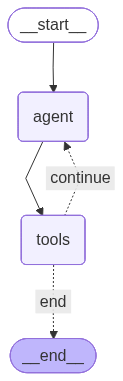

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
def run_document_agent():
  print("\n DRAFTER")
  state = {"messages": []}

  for step in app.stream(state, stream_mode="values"):
    if "messages" in step:
      print_messages(step["messages"])

  print("\n Drafter Finished")

In [25]:
run_document_agent()


 DRAFTER

 AI: [{'type': 'text', 'text': "I'm ready too! Let's start with a blank document. What content would you like to add?", 'extras': {'signature': 'CosDAY89a18tClEZmcdaqLiHOExYSZuIf3JBvOTlfwOFCzyiJWDqIO5+BIvHCdFUMzsNHJ/ORkiauXN7fb0WXk5VgpFg1spHepnb4w8F+PW5eUUCJDoaIF+/Nj7V4FWHzsIFMz6cu0RhvpBWSA7yr0YFoJ05pVRUeGYcbj1lI7qatzbySEDXxkYDRj3RYnDUiqK+DMuJm8vScN3WFSaj5iCysOrw2qw1v/AY9/cVRoBs+xT92YheITBgNwe3tjxvN9IbqI2PEYKGA7HvWSaPwwB5O7ufLymSwBOlidwcC9KY8GeBySDwwL9pEdJltlNgfSIMPGYqLnVOW6m+YspHsytxtf8ysIXomA6XeekIkmKyJfUe9ijpFgsijhXsFpysTDsRpcaiACDeo0CbvJJO0KYJEs2P2i3uiJejEeENQ+AhUewIdQaMhNouYw8TAbVShSQkY0c2Yb+YGKz5mFxLvxrW+RLji7hznklQtzCty1gjCPNrqow7fTeCnTby7/GK+QfOEuyXPrTsIYyt8+E='}}]

What would you like to do with the document? Write me an email to tom saying I cannot make it to the meeting

 User: Write me an email to tom saying I cannot make it to the meeting

 AI: 
Using tools: ['update']

 Tool Result Document has been updated successfully! The current content is:
Hi Tom,

I can't